In [27]:
import numpy as np                                     # Matlab like syntax for linear algebra and functions
import matplotlib.pyplot as plt                        # Plots and figures like you know them from Matlab

In [ ]:
r = np.random             # Random generator
r.seed(42)                # Set a random seed (but a fixed one)
N_entries  = 1_000_000    # Notice that Python (3) allows us to write undercores in numeric values without it changing the value. 
                          # Useful as a 1000 separater, in phone numbers or similar cases.

In [ ]:
# Calculate ROC curve from two histograms (hist1 is signal, hist2 is background):
def calc_ROC(hist1, hist2) :

    # First we extract the entries (y values) and the edges of the histograms:
    # Note how the "_" is simply used for the rest of what e.g. "hist1" returns (not really of our interest)
    y_sig, x_sig_edges, _ = hist1 
    y_bkg, x_bkg_edges, _ = hist2
    
    # Check that the two histograms have the same x edges:
    if np.array_equal(x_sig_edges, x_bkg_edges) :
        
        # Extract the center positions (x values) of the bins (both signal or background works - equal binning)
        x_centers = 0.5*(x_sig_edges[1:] + x_sig_edges[:-1])
        
        # Calculate the integral (sum) of the signal and background:
        integral_sig = float(y_sig.sum())
        integral_bkg = float(y_bkg.sum())
    
        # Initialize empty arrays for the True Positive Rate (TPR) and the False Positive Rate (FPR):
        TPR = np.zeros_like(y_sig) # True positive rate (sensitivity)
        FPR = np.zeros_like(y_sig) # False positive rate ()
        
        # Loop over all bins (x_centers) of the histograms and calculate TN, FP, FN, TP, FPR, and TPR for each bin:
        for i, x in enumerate(x_centers): 
            
            # The cut mask
            cut = (x_centers < x)
            
            # True positive
            TP = np.sum(y_sig[~cut]) / integral_sig    # True positives
            FN = np.sum(y_sig[cut]) / integral_sig     # False negatives
            TPR[i] = TP / (TP + FN)                    # True positive rate
            
            # True negative
            TN = np.sum(y_bkg[cut]) / integral_bkg      # True negatives (background)
            FP = np.sum(y_bkg[~cut]) / integral_bkg     # False positives
            FPR[i] = FP / (FP + TN)                     # False positive rate            
            
        return FPR, TPR
    
    else:
        AssertionError("Signal and Background histograms have different bins and/or ranges")

In [30]:
N_sigma=2.2
mean_sig = 5 + N_sigma / np.sqrt(2.0)
mean_bkg = 5 - N_sigma / np.sqrt(2.0)

In [31]:
data_sig = r.normal(loc=mean_sig, scale=1, size=(N_entries))
data_bkg = r.normal(loc=mean_bkg, scale=1, size=(N_entries))

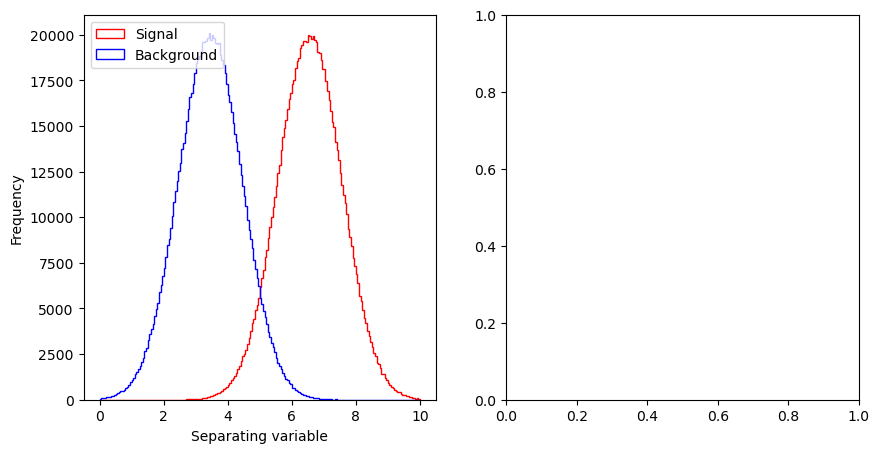

In [ ]:
N_bins = 200
xmin = 0
xmax = 10

fig,ax=plt.subplots(1,2, figsize = (10,5))

hist_sig = []
hist_bkg = []

y_sig = np.zeros((N_bins))
y_bkg = np.zeros_like(y_sig)


hist_sig.append(ax[0].hist(data_sig, bins=N_bins, range=(xmin, xmax), histtype='step', lw=1, label='Signal', color='red'))
hist_bkg.append(ax[0].hist(data_bkg, bins=N_bins, range=(xmin, xmax), histtype='step', lw=1, label='Background', color='blue'))
ax[0].set_xlabel('Separating variable')
ax[0].set_ylabel('Frequency')
#ax[0].text(0.75, 0.9, "hist", size=16, verticalalignment='center', transform=ax[0].transAxes)

ax[0].legend(loc='upper left')
#fig

#hist_sig[0]

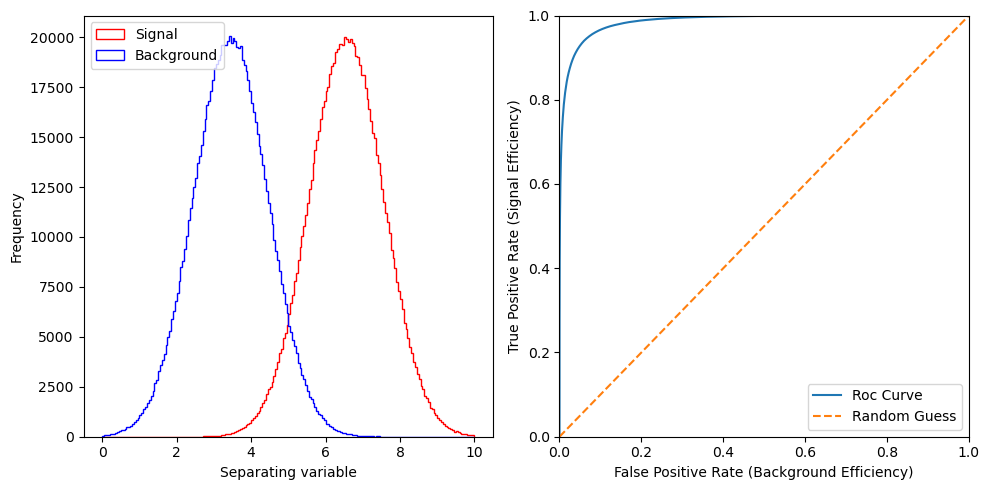

In [33]:
# Calculate FPR and TPR by calc_ROC:
FPR, TPR = calc_ROC(hist_sig[0], hist_bkg[0])    

# Plot the roc-curve:
ax[1].plot(FPR, TPR, '-', label="Roc Curve")

# Add text:
#ax[1].text("asf", size=12, verticalalignment='center', transform=ax[1].transAxes)


# Plot diagonal line:
ax[1].plot([0, 1], [0, 1], '--', label='Random Guess')

# Set figure options:
ax[1].set(xlabel='False Positive Rate (Background Efficiency)', ylabel='True Positive Rate (Signal Efficiency)', xlim=(0, 1), ylim=(0, 1))
ax[1].legend()

fig.tight_layout()
fig

In [ ]:
#fig.savefig('ROCcurves_GaussianSeparations.pdf', dpi=600, bbox_inches='tight')